In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
print(torch.__version__)
print("GPU available:", torch.cuda.is_available())

2.10.0+cu128
GPU available: True


In [7]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.empty(out_features, in_features))

        # same init PyTorch uses for Linear
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        nn.init.ones_(self.gate_scores)  # start all gates open

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return x @ pruned_weights.T + self.bias

In [19]:
class SelfPruningNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            PrunableLinear(3072, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            PrunableLinear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),
            PrunableLinear(128, 64),
            nn.ReLU(),
            PrunableLinear(64, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

    def sparsity_loss(self):
        total = 0
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                total += torch.sigmoid(m.gate_scores).sum()
        return total

    def sparsity_level(self, threshold=1e-2):
        total, pruned = 0, 0
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                gates = torch.sigmoid(m.gate_scores)
                pruned += (gates < threshold).sum().item()
                total += gates.numel()
        return 100.0 * pruned / total

In [20]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_train)
test_set  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_set, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
def train(lam, epochs=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SelfPruningNet().to(device)

    gate_params = [p for n, p in model.named_parameters() if "gate_scores" in n]
    other_params = [p for n, p in model.named_parameters() if "gate_scores" not in n]

    optimizer = optim.Adam([
        {"params": other_params, "lr": 1e-3, "weight_decay": 1e-4},
        {"params": gate_params,  "lr": 5e-3}
    ])

    # warmup for 5 epochs, then cosine decay
    def lr_lambda(epoch):
        if epoch < 5:
            return (epoch+1) / 5
        return 1.0

    warmup = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    cosine = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs-5)
    scheduler = optim.lr_scheduler.SequentialLR(optimizer, [warmup, cosine], milestones=[5])
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels) + lam * model.sparsity_loss()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()

        if (epoch + 1) % 10 == 0:
            print(f"  [λ={lam}] Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Sparsity: {model.sparsity_level():.1f}%")

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = 100.0 * correct / total
    sparsity = model.sparsity_level()
    print(f"\n  [λ={lam}] Test Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%\n")
    return model, acc, sparsity

In [27]:
results = {}
lambdas = [1e-4, 1e-3, 1e-2]  # shifted an order of magnitude higher

for lam in lambdas:
    print(f"Training with λ = {lam} ...")
    model, acc, sparsity = train(lam)
    results[lam] = {"model": model, "accuracy": acc, "sparsity": sparsity}

print("\nFinal Results")
print(f"{'Lambda':<12} {'Test Accuracy':>15} {'Sparsity Level':>16}")
print("-" * 45)
for lam, r in results.items():
    print(f"{lam:<12} {r['accuracy']:>14.2f}% {r['sparsity']:>15.2f}%")

Training with λ = 0.0001 ...
  [λ=0.0001] Epoch 10/50 | Loss: 5.7024 | Sparsity: 0.0%
  [λ=0.0001] Epoch 20/50 | Loss: 2.5675 | Sparsity: 64.2%
  [λ=0.0001] Epoch 30/50 | Loss: 2.0666 | Sparsity: 86.3%
  [λ=0.0001] Epoch 40/50 | Loss: 1.9107 | Sparsity: 89.0%
  [λ=0.0001] Epoch 50/50 | Loss: 1.8787 | Sparsity: 89.3%

  [λ=0.0001] Test Accuracy: 56.40% | Sparsity: 89.32%

Training with λ = 0.001 ...
  [λ=0.001] Epoch 10/50 | Loss: 36.3213 | Sparsity: 0.0%
  [λ=0.001] Epoch 20/50 | Loss: 8.3071 | Sparsity: 98.2%
  [λ=0.001] Epoch 30/50 | Loss: 4.3935 | Sparsity: 99.6%
  [λ=0.001] Epoch 40/50 | Loss: 3.3645 | Sparsity: 99.7%
  [λ=0.001] Epoch 50/50 | Loss: 3.1751 | Sparsity: 99.7%

  [λ=0.001] Test Accuracy: 55.84% | Sparsity: 99.71%

Training with λ = 0.01 ...
  [λ=0.01] Epoch 10/50 | Loss: 346.9184 | Sparsity: 0.0%
  [λ=0.01] Epoch 20/50 | Loss: 67.4613 | Sparsity: 99.9%
  [λ=0.01] Epoch 30/50 | Loss: 28.1633 | Sparsity: 100.0%
  [λ=0.01] Epoch 40/50 | Loss: 17.3980 | Sparsity: 100.0%
 

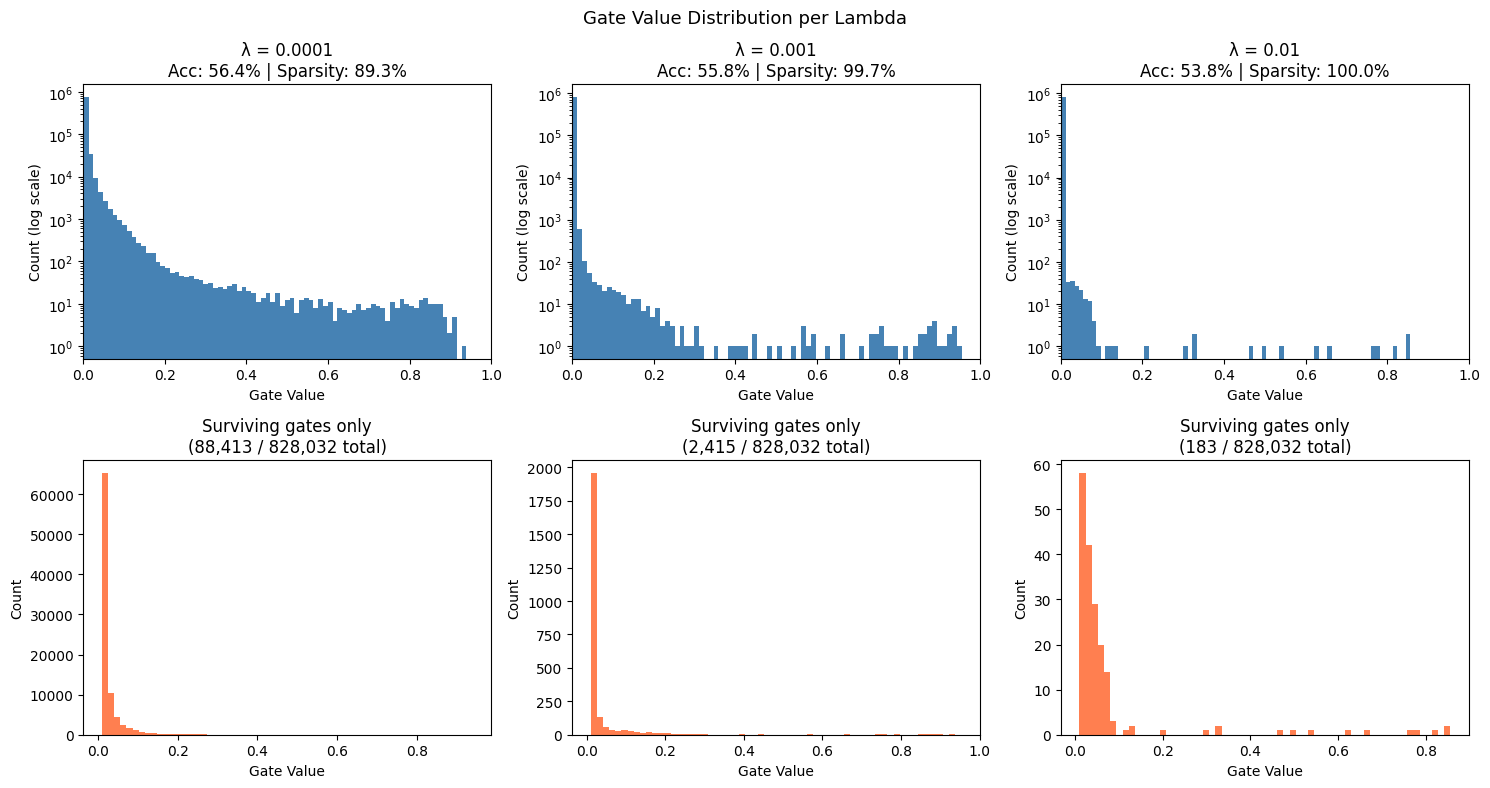

In [29]:
def plot_gate_distribution(results):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("Gate Value Distribution per Lambda", fontsize=13)

    for i, (lam, r) in enumerate(results.items()):
        all_gates = []
        for m in r["model"].modules():
            if isinstance(m, PrunableLinear):
                gates = torch.sigmoid(m.gate_scores).detach().cpu().numpy().flatten()
                all_gates.append(gates)
        all_gates = np.concatenate(all_gates)

        # top row — full view with log scale
        axes[0, i].hist(all_gates, bins=80, color="steelblue", edgecolor="none")
        axes[0, i].set_yscale("log")
        axes[0, i].set_title(f"λ = {lam}\nAcc: {r['accuracy']:.1f}% | Sparsity: {r['sparsity']:.1f}%")
        axes[0, i].set_xlabel("Gate Value")
        axes[0, i].set_ylabel("Count (log scale)")
        axes[0, i].set_xlim(0, 1)

        # bottom row — zoomed into surviving gates (>0.01)
        surviving = all_gates[all_gates > 0.01]
        if len(surviving) > 0:
            axes[1, i].hist(surviving, bins=60, color="coral", edgecolor="none")
            axes[1, i].set_title(f"Surviving gates only\n({len(surviving):,} / {len(all_gates):,} total)")
        else:
            axes[1, i].text(0.5, 0.5, "No surviving gates", ha="center", va="center")
            axes[1, i].set_title("Surviving gates only\n(fully pruned)")
        axes[1, i].set_xlabel("Gate Value")
        axes[1, i].set_ylabel("Count")

    plt.tight_layout()
    plt.savefig("gate_distribution.png", dpi=150)
    plt.show()

plot_gate_distribution(results)